In [1]:
# GPU check + RAPIDS install
!nvidia-smi

# RAPIDS install for Colab
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py

Sun Apr 26 15:22:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Python env
import os
import json
import glob
import time
import shutil

import numpy as np
import pandas as pd
import cupy as cp
import cudf

import matplotlib.pyplot as plt

from google.colab import userdata

from cuml.preprocessing import StandardScaler
from cuml.decomposition import PCA
from cuml.manifold import UMAP
from cuml.neighbors import NearestNeighbors
from cuml.cluster import DBSCAN, KMeans

from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
SAMPLE_SIZE = 100_000

FEATURE_COLS = [
    "n_events",
    "n_logons",
    "n_distinct_pcs",
    "n_after_hours",
    "n_weekend",
    "first_hour",
    "last_hour",
    "hour_span",
]

print("RAPIDS ready.")


RAPIDS ready.


In [3]:
# Kaggle credentials + download logon.csv only
os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_creds = {
    "username": userdata.get("KAGGLE_USERNAME"),
    "key": userdata.get("KAGGLE_KEY"),
}

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)

os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Downloading logon.csv only...")
!kaggle datasets download -d mrajaxnp/cert-insider-threat-detection-research -f logon.csv
!unzip -o logon.csv.zip

if os.path.exists("logon.csv"):
    size_mb = os.path.getsize("logon.csv") / (1024 * 1024)
    print(f"Downloaded logon.csv: {size_mb:.1f} MB")
else:
    raise FileNotFoundError("logon.csv was not found.")


Dataset URL: https://www.kaggle.com/datasets/mrajaxnp/cert-insider-threat-detection-research
License(s): unknown
100% 89.9M/89.9M [00:00<00:00, 130MB/s]

Archive:  logon.csv.zip
  inflating: logon.csv               
Downloaded logon.csv: 230.4 MB


In [4]:
# Load logon.csv on GPU with cuDF
LOGON_PATH = "/content/logon.csv"

df_logon = cudf.read_csv(LOGON_PATH)

print("Shape:", df_logon.shape)
print("Columns:", list(df_logon.columns))

df_logon.head()


Shape: (3530285, 5)
Columns: ['id', 'date', 'user', 'pc', 'activity']


,id,date,user,pc,activity
0,{F3X8-Y2GT43DR-4906OHBL},01/02/2010 02:19:18,DNS1758,PC-0414,Logon
1,{B4Q0-D0GM24KN-3704MAII},01/02/2010 02:31:12,DNS1758,PC-0414,Logoff
2,{T7J1-D4HK34KV-5476TCIJ},01/02/2010 02:34:02,DNS1758,PC-5313,Logon
3,{S4Y6-D8MQ05SA-0759HLIS},01/02/2010 02:53:30,DNS1758,PC-5313,Logoff
4,{F3P0-E7FH78CV-4874FRGZ},01/02/2010 04:07:31,DNS1758,PC-0012,Logon


In [5]:
# GPU feature engineering, one row per user-day

# Parse timestamp on GPU
df_logon["date"] = cudf.to_datetime(df_logon["date"])

# Extract time features
df_logon["hour"] = df_logon["date"].dt.hour.astype("int16")
df_logon["day"] = df_logon["date"].dt.floor("D")
df_logon["dow"] = df_logon["date"].dt.weekday.astype("int16")

# Behavioral flags
df_logon["is_logon"] = (df_logon["activity"] == "Logon").astype("int8")
df_logon["is_after_hours"] = (
    (df_logon["hour"] < 7) | (df_logon["hour"] >= 19)
).astype("int8")
df_logon["is_weekend"] = (df_logon["dow"] >= 5).astype("int8")

# Aggregate to user-day
features = (
    df_logon
    .groupby(["user", "day"])
    .agg({
        "id": "count",
        "is_logon": "sum",
        "pc": "nunique",
        "is_after_hours": "sum",
        "is_weekend": "sum",
        "hour": ["min", "max"],
    })
    .reset_index()
)

features.columns = [
    "user",
    "day",
    "n_events",
    "n_logons",
    "n_distinct_pcs",
    "n_after_hours",
    "n_weekend",
    "first_hour",
    "last_hour",
]

features["hour_span"] = features["last_hour"] - features["first_hour"]

print("User-day feature matrix shape:", features.shape)
print("\nDistribution snapshot:")
print(features[FEATURE_COLS].describe().to_pandas().round(2))

features.head()


User-day feature matrix shape: (1394010, 10)

Distribution snapshot:
         n_events    n_logons  n_distinct_pcs  n_after_hours   n_weekend  \
count  1394010.00  1394010.00      1394010.00     1394010.00  1394010.00   
mean         2.53        1.40            1.12           0.25        0.06   
std          1.23        0.73            0.56           0.89        0.43   
min          1.00        0.00            1.00           0.00        0.00   
25%          2.00        1.00            1.00           0.00        0.00   
50%          2.00        1.00            1.00           0.00        0.00   
75%          3.00        2.00            1.00           0.00        0.00   
max         18.00       10.00            7.00          14.00       16.00   

       first_hour   last_hour   hour_span  
count  1394010.00  1394010.00  1394010.00  
mean         7.38       16.97        9.60  
std          1.09        1.48        1.79  
min          0.00        0.00        0.00  
25%          7.00       16

,user,day,n_events,n_logons,n_distinct_pcs,n_after_hours,n_weekend,first_hour,last_hour,hour_span
0,AAB0162,2010-01-04,2,1,1,0,0,7,18,11
1,AAB0162,2010-01-05,2,1,1,0,0,7,18,11
2,AAB0162,2010-01-06,2,1,1,0,0,7,18,11
3,AAB0162,2010-01-07,2,1,1,0,0,7,18,11
4,AAB0162,2010-01-08,2,1,1,0,0,7,18,11


In [6]:
# Sample + scale on GPU

if len(features) > SAMPLE_SIZE:
    features_sampled = features.sample(
        n=SAMPLE_SIZE,
        random_state=RANDOM_STATE
    ).reset_index(drop=True)
    print(f"Sampled {SAMPLE_SIZE:,} from {len(features):,} user-days.")
else:
    features_sampled = features.copy()
    print(f"Using full dataset: {len(features_sampled):,} user-days.")

X_gpu = features_sampled[FEATURE_COLS].astype("float32")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_gpu)

print("Scaled matrix:", X_scaled.shape)
print("GPU scaling complete.")
X_scaled


Sampled 100,000 from 1,394,010 user-days.
Scaled matrix: (100000, 8)
GPU scaling complete.


,0,1,2,3,4,5,6,7
0,-0.430784,-0.542202,-0.218773,-0.286438,-0.134903,0.573163,0.690526,0.223596
1,-0.430784,-0.542202,-0.218773,-0.286438,-0.134903,-0.342945,-1.325472,-0.889042
2,-0.430784,-0.542202,-0.218773,-0.286438,-0.134903,0.573163,0.690526,0.223596
3,-0.430784,-0.542202,-0.218773,-0.286438,-0.134903,0.573163,0.018527,-0.332723
4,-0.430784,-0.542202,-0.218773,-0.286438,-0.134903,0.573163,-0.653472,-0.889042
...,...,...,...,...,...,...,...,...
99995,0.376745,0.817552,-0.218773,-0.286438,-0.134903,-0.342945,-0.653472,-0.332723
99996,-0.430784,-0.542202,-0.218773,-0.286438,-0.134903,0.573163,0.690526,0.223596
99997,-0.430784,-0.542202,-0.218773,-0.286438,-0.134903,-0.342945,-0.653472,-0.332723
99998,-0.430784,-0.542202,-0.218773,-0.286438,-0.134903,-0.342945,0.018527,0.223596


In [7]:
# GPU PCA + GPU UMAP
# These are for visualization only. DBSCAN still uses the full 8D X_scaled matrix.

print("Running GPU PCA...")
t0 = time.time()

# cuML PCA in this Colab/RAPIDS version does not accept random_state.
pca = PCA(n_components=2, output_type="cupy")
X_pca = pca.fit_transform(X_scaled)

pca_var = cp.asarray(pca.explained_variance_ratio_)
pca_total = float(cp.sum(pca_var).get())

print(f"GPU PCA done in {time.time() - t0:.1f}s")
print("PCA explained variance:", cp.round(pca_var, 3).get())
print(f"PCA total explained variance: {pca_total:.1%}")

print("\nRunning GPU UMAP...")
t0 = time.time()

umap_model = UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    random_state=RANDOM_STATE,
    output_type="cupy",
)

X_umap = umap_model.fit_transform(X_scaled)

print(f"GPU UMAP done in {time.time() - t0:.1f}s")
print("UMAP shape:", X_umap.shape)



Running GPU PCA...
GPU PCA done in 0.6s
PCA explained variance: [0.552 0.161]
PCA total explained variance: 71.3%

Running GPU UMAP...
GPU UMAP done in 17.6s
UMAP shape: (100000, 2)


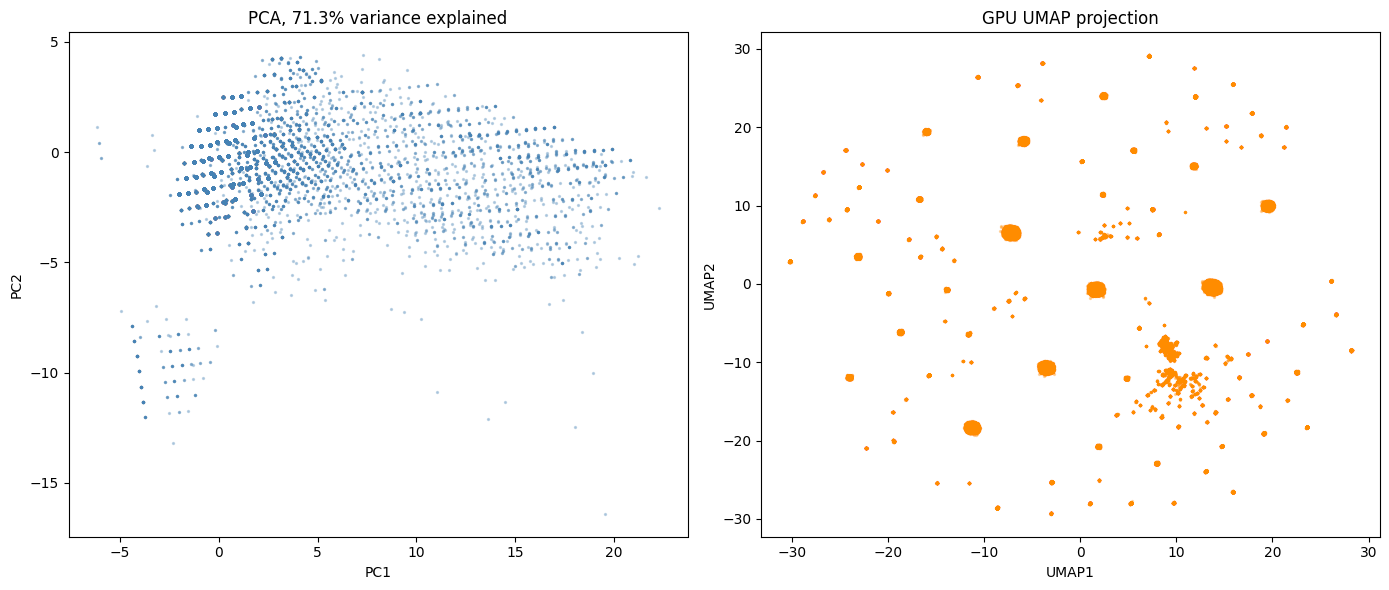

Saved: /content/01_pre_clustering.png


In [8]:
# Pre-clustering visualization

X_pca_np = cp.asnumpy(X_pca)
X_umap_np = cp.asnumpy(X_umap)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca_np[:, 0], X_pca_np[:, 1], s=2, alpha=0.3, c="steelblue")
axes[0].set_title(f"PCA, {pca_total:.1%} variance explained")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_umap_np[:, 0], X_umap_np[:, 1], s=2, alpha=0.3, c="darkorange")
axes[1].set_title("GPU UMAP projection")
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")

plt.tight_layout()
plt.savefig("/content/01_pre_clustering.png", dpi=120, bbox_inches="tight")
plt.show()

print("Saved: /content/01_pre_clustering.png")



Running GPU nearest neighbors...
GPU k-distance finished in 0.5s


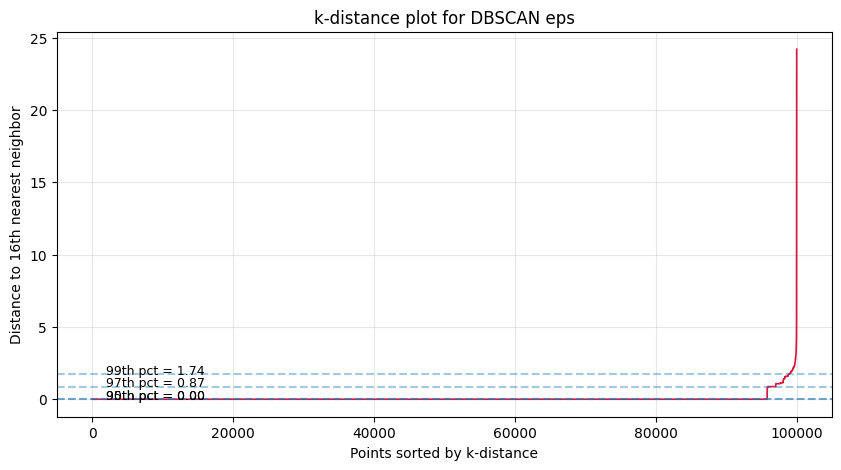

Candidate eps values:
90th percentile: 0.000
95th percentile: 0.000
97th percentile: 0.872
99th percentile: 1.745


In [9]:
# GPU k-distance plot for DBSCAN eps

MIN_SAMPLES = 16

print("Running GPU nearest neighbors...")
t0 = time.time()

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES, output_type="cupy")
nn.fit(X_scaled)

distances, _ = nn.kneighbors(X_scaled)

k_distances = cp.sort(distances[:, -1])
k_distances_np = cp.asnumpy(k_distances)

print(f"GPU k-distance finished in {time.time() - t0:.1f}s")

plt.figure(figsize=(10, 5))
plt.plot(k_distances_np, linewidth=1.2, color="crimson")
plt.xlabel("Points sorted by k-distance")
plt.ylabel(f"Distance to {MIN_SAMPLES}th nearest neighbor")
plt.title("k-distance plot for DBSCAN eps")
plt.grid(alpha=0.3)

for pct in [90, 95, 97, 99]:
    val = np.percentile(k_distances_np, pct)
    plt.axhline(val, linestyle="--", alpha=0.4)
    plt.text(len(k_distances_np) * 0.02, val, f"{pct}th pct = {val:.2f}", fontsize=9)

plt.savefig("/content/02_kdistance.png", dpi=120, bbox_inches="tight")
plt.show()

print("Candidate eps values:")
for pct in [90, 95, 97, 99]:
    print(f"{pct}th percentile: {np.percentile(k_distances_np, pct):.3f}")


In [10]:
# GPU DBSCAN fit
# Pick eps from the k-distance plot. If the 95th percentile is zero, use the
# first positive candidate so DBSCAN forms real neighborhoods, not exact matches.

EPS_CANDIDATE_PERCENTILES = [95, 97, 99]
eps_candidates = {
    pct: float(np.percentile(k_distances_np, pct))
    for pct in EPS_CANDIDATE_PERCENTILES
}

EPS_PERCENTILE = next(
    pct for pct in EPS_CANDIDATE_PERCENTILES
    if eps_candidates[pct] > 1e-8
)
EPS = eps_candidates[EPS_PERCENTILE]

print("DBSCAN eps candidates:")
for pct, val in eps_candidates.items():
    print(f"  {pct}th percentile: {val:.8f}")

print(f"\nUsing eps={EPS:.8f} from the {EPS_PERCENTILE}th percentile, min_samples={MIN_SAMPLES}")

t0 = time.time()

dbscan = DBSCAN(
    eps=EPS,
    min_samples=MIN_SAMPLES,
    metric="euclidean",
    output_type="cupy",
)

labels_db = dbscan.fit_predict(X_scaled)
labels_db_np = cp.asnumpy(labels_db)

print(f"GPU DBSCAN finished in {time.time() - t0:.1f}s")

n_clusters_db = len(set(labels_db_np)) - (1 if -1 in labels_db_np else 0)
n_noise = int((labels_db_np == -1).sum())

print(f"DBSCAN clusters found: {n_clusters_db}")
print(f"DBSCAN noise/anomalies: {n_noise:,} ({n_noise / len(labels_db_np):.1%})")

unique, counts = np.unique(labels_db_np, return_counts=True)
print("\nCluster sizes:")
for u, c in sorted(zip(unique, counts), key=lambda x: -x[1])[:10]:
    label = "NOISE" if u == -1 else f"cluster {u}"
    print(f"{label:>12}: {c:>7,} points ({c / len(labels_db_np):.1%})")



DBSCAN eps candidates:
  95th percentile: 0.00000000
  97th percentile: 0.87240213
  99th percentile: 1.74479556

Using eps=0.87240213 from the 97th percentile, min_samples=16
[2026-04-26 15:23:03.136] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 25010 -> 21474. Using the larger integer type might result in better performance
GPU DBSCAN finished in 1.6s
DBSCAN clusters found: 86
DBSCAN noise/anomalies: 2,658 (2.7%)

Cluster sizes:
   cluster 1:  29,798 points (29.8%)
   cluster 0:  26,423 points (26.4%)
   cluster 4:   9,405 points (9.4%)
   cluster 3:   9,179 points (9.2%)
   cluster 6:   3,206 points (3.2%)
   cluster 2:   3,070 points (3.1%)
       NOISE:   2,658 points (2.7%)
   cluster 9:   2,501 points (2.5%)
  cluster 14:   1,739 points (1.7%)
  cluster 15:   1,440 points (1.4%)


In [11]:
# K-Means on GPU, silhouette on small CPU sample

print("\nRunning GPU K-Means k=2..8...")

rng = np.random.default_rng(RANDOM_STATE)
sil_sample_n = min(10_000, len(features_sampled))
sil_idx = rng.choice(len(features_sampled), size=sil_sample_n, replace=False)

# FIX: use iloc for row selection
X_sil_cpu = X_scaled.iloc[sil_idx].to_pandas().values

best_k = None
best_sil = -999
best_labels_km = None

for k in range(2, 9):
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
        output_type="cupy",
    )

    labels_tmp = km.fit_predict(X_scaled)
    labels_tmp_np = cp.asnumpy(labels_tmp)

    sil = silhouette_score(X_sil_cpu, labels_tmp_np[sil_idx])
    print(f"k={k}: silhouette={sil:.3f}")

    if sil > best_sil:
        best_k = k
        best_sil = sil
        best_labels_km = labels_tmp

labels_km = best_labels_km
labels_km_np = cp.asnumpy(labels_km)

print(f"\nBest K-Means: k={best_k}, silhouette={best_sil:.3f}")

# DBSCAN silhouette excluding noise
normal_mask = labels_db_np != -1

if normal_mask.sum() > 100 and len(set(labels_db_np[normal_mask])) > 1:
    normal_idx_all = np.where(normal_mask)[0]
    db_sil_n = min(10_000, len(normal_idx_all))
    db_sil_idx = rng.choice(normal_idx_all, size=db_sil_n, replace=False)

    X_db_sil_cpu = X_scaled.iloc[db_sil_idx].to_pandas().values

    sil_db = silhouette_score(
        X_db_sil_cpu,
        labels_db_np[db_sil_idx],
    )

    print(f"DBSCAN silhouette excluding noise: {sil_db:.3f}")
else:
    sil_db = None
    print("DBSCAN silhouette skipped because there is only one non-noise cluster.")




Running GPU K-Means k=2..8...
k=2: silhouette=0.816
k=3: silhouette=0.707
k=4: silhouette=0.459
k=5: silhouette=0.305
k=6: silhouette=0.307
k=7: silhouette=0.309
k=8: silhouette=0.335

Best K-Means: k=2, silhouette=0.816
DBSCAN silhouette excluding noise: 0.372


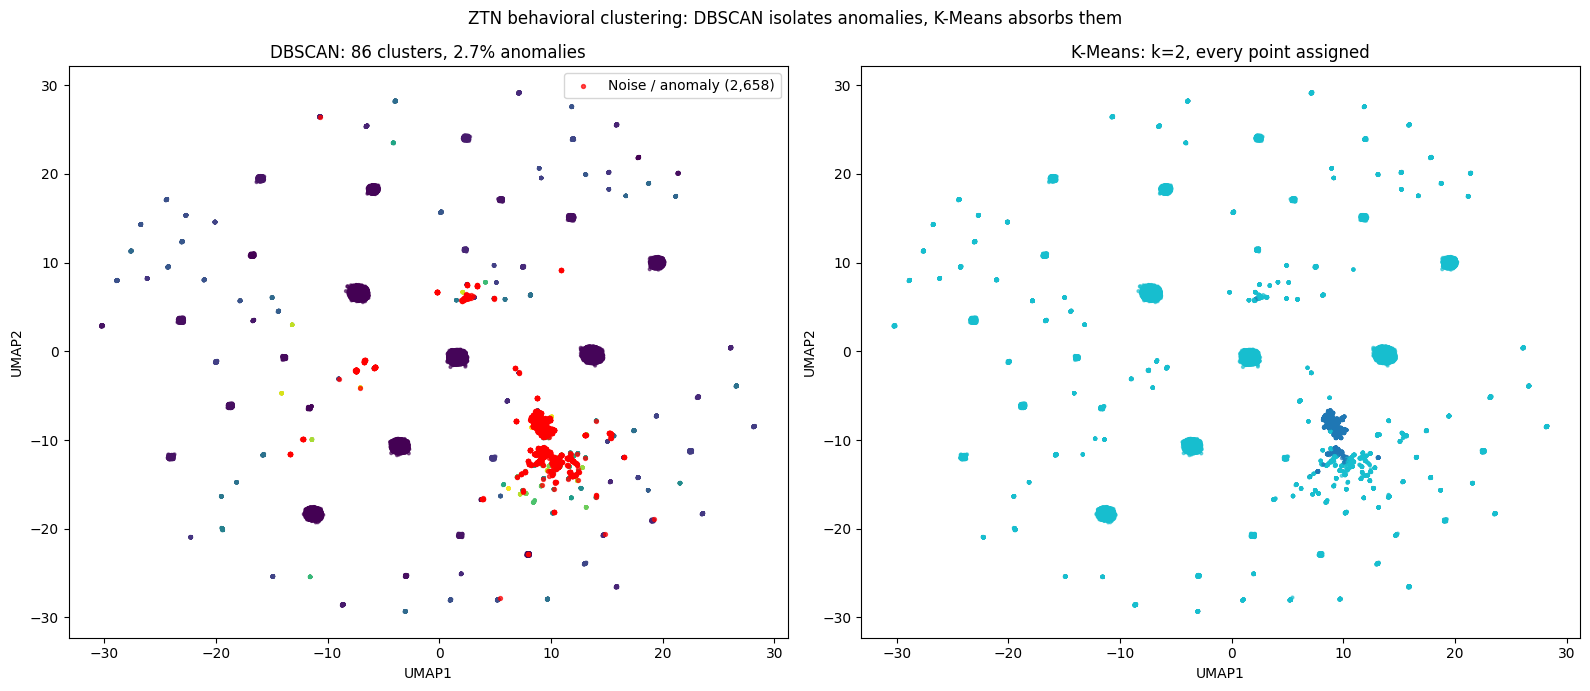

Saved: /content/03_dbscan_vs_kmeans.png


In [12]:
# DBSCAN vs K-Means report plot

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

noise_mask = labels_db_np == -1

axes[0].scatter(
    X_umap_np[~noise_mask, 0],
    X_umap_np[~noise_mask, 1],
    c=labels_db_np[~noise_mask],
    cmap="viridis",
    s=4,
    alpha=0.6,
)
axes[0].scatter(
    X_umap_np[noise_mask, 0],
    X_umap_np[noise_mask, 1],
    c="red",
    s=8,
    alpha=0.7,
    label=f"Noise / anomaly ({noise_mask.sum():,})",
)
axes[0].set_title(
    f"DBSCAN: {n_clusters_db} clusters, {noise_mask.mean():.1%} anomalies"
)
axes[0].set_xlabel("UMAP1")
axes[0].set_ylabel("UMAP2")
axes[0].legend(loc="upper right")

axes[1].scatter(
    X_umap_np[:, 0],
    X_umap_np[:, 1],
    c=labels_km_np,
    cmap="tab10",
    s=4,
    alpha=0.6,
)
axes[1].set_title(f"K-Means: k={best_k}, every point assigned")
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")

plt.suptitle("ZTN behavioral clustering: DBSCAN isolates anomalies, K-Means absorbs them")
plt.tight_layout()
plt.savefig("/content/03_dbscan_vs_kmeans.png", dpi=120, bbox_inches="tight")
plt.show()

print("Saved: /content/03_dbscan_vs_kmeans.png")


In [13]:
# Profile anomalies

features_sampled["cluster_db"] = cudf.Series(labels_db)
features_sampled["cluster_km"] = cudf.Series(labels_km)
features_sampled["is_anomaly"] = (features_sampled["cluster_db"] == -1).astype("int8")

features_pd = features_sampled.to_pandas()

profile = (
    features_pd
    .groupby("is_anomaly")[FEATURE_COLS]
    .mean()
    .round(2)
)

profile.index = ["Normal", "Anomaly"]

print("=" * 70)
print("NORMAL VS ANOMALY PROFILE")
print("=" * 70)
print(profile.T)

ratio = (profile.loc["Anomaly"] / profile.loc["Normal"].replace(0, np.nan)).round(2)

print("\nAnomaly / Normal ratio:")
print(ratio.sort_values(ascending=False).to_string())

anomalies = features_pd[features_pd["is_anomaly"] == 1].copy()

anomalies["extremity_score"] = (
    anomalies["n_after_hours"] * 2
    + anomalies["n_distinct_pcs"] * 3
    + (anomalies["first_hour"] < 6).astype(int) * 5
    + (anomalies["last_hour"] > 22).astype(int) * 5
)

top_anomalies = anomalies.sort_values("extremity_score", ascending=False).head(10)

print("\nTop 10 anomalous user-days:")
print(top_anomalies[["user", "day"] + FEATURE_COLS].to_string(index=False))


NORMAL VS ANOMALY PROFILE
                Normal  Anomaly
n_events          2.39     7.69
n_logons          1.33     4.01
n_distinct_pcs    1.06     3.49
n_after_hours     0.15     4.09
n_weekend         0.05     0.37
first_hour        7.47     4.01
last_hour        16.92    18.73
hour_span         9.46    14.72

Anomaly / Normal ratio:
n_after_hours     27.27
n_weekend          7.40
n_distinct_pcs     3.29
n_events           3.22
n_logons           3.02
hour_span          1.56
last_hour          1.11
first_hour         0.54

Top 10 anomalous user-days:
   user        day  n_events  n_logons  n_distinct_pcs  n_after_hours  n_weekend  first_hour  last_hour  hour_span
DNS1768 2010-12-21        14         7               7             10          0           5         23         18
JFG1049 2010-11-03        13         7               6             10          0           4         23         19
CAM3050 2011-05-19        13         7               6             10          0           4   

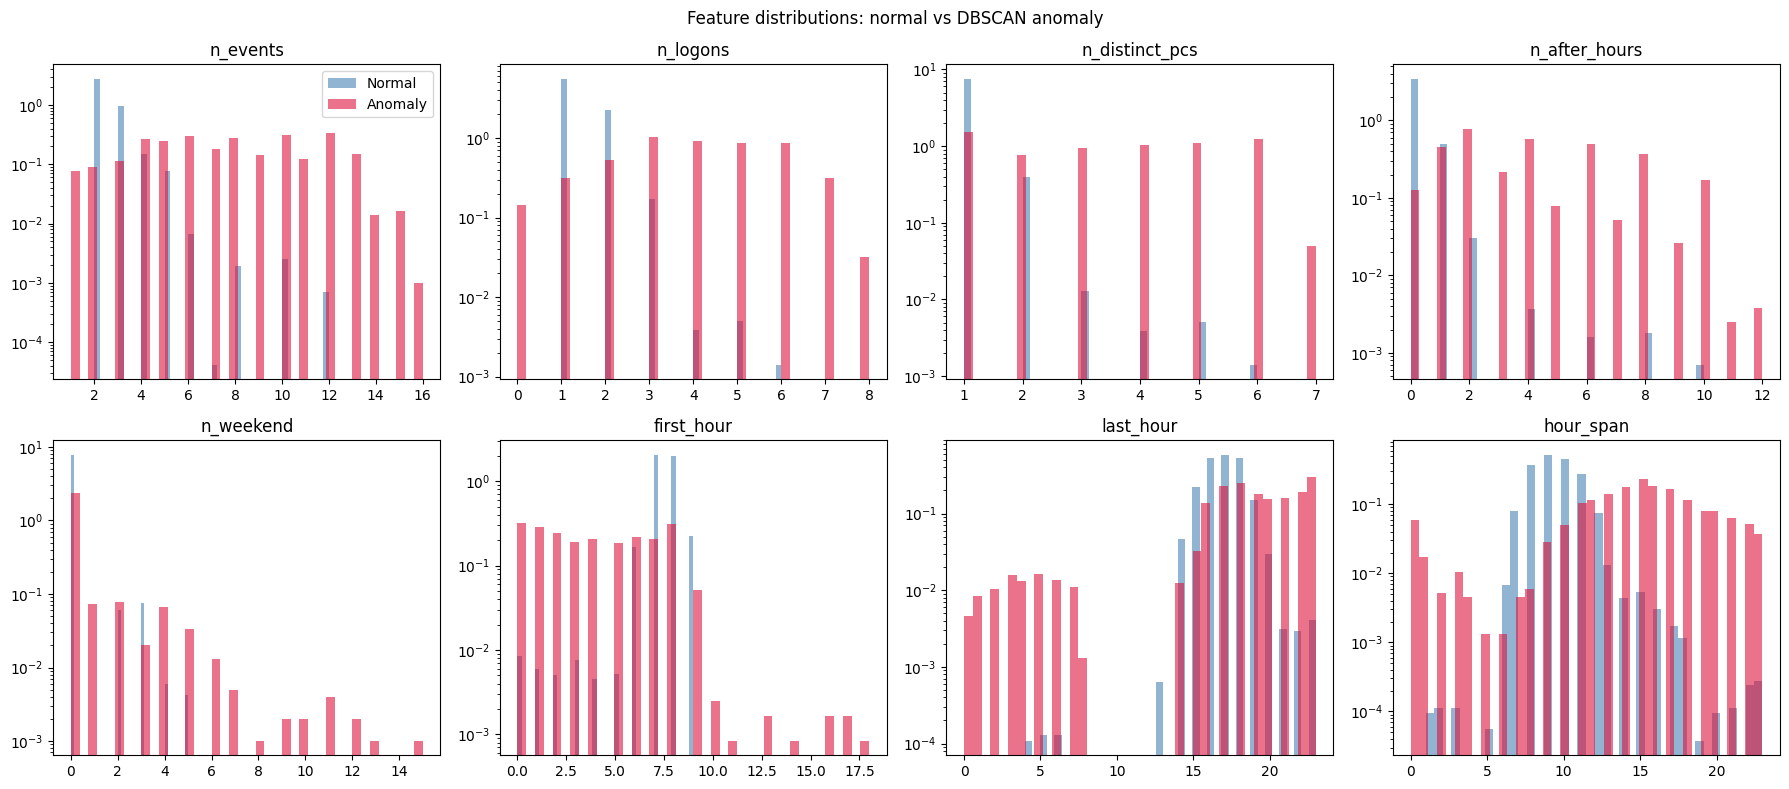

Saved: /content/04_feature_distributions.png


In [14]:
# Feature distribution plot

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]

    normal_vals = features_pd[features_pd["is_anomaly"] == 0][col]
    anom_vals = features_pd[features_pd["is_anomaly"] == 1][col]

    ax.hist(normal_vals, bins=40, alpha=0.6, label="Normal", color="steelblue", density=True)
    ax.hist(anom_vals, bins=40, alpha=0.6, label="Anomaly", color="crimson", density=True)
    ax.set_title(col)
    ax.set_yscale("log")

    if i == 0:
        ax.legend()

plt.suptitle("Feature distributions: normal vs DBSCAN anomaly")
plt.tight_layout()
plt.savefig("/content/04_feature_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

print("Saved: /content/04_feature_distributions.png")



In [15]:
# Save Task 2 outputs

OUT_DIR = "/content/task2_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

features_pd.to_csv(f"{OUT_DIR}/user_day_features_clustered.csv", index=False)
anomalies.to_csv(f"{OUT_DIR}/anomalies_dbscan.csv", index=False)
top_anomalies.to_csv(f"{OUT_DIR}/top_anomalies.csv", index=False)

summary = {
    "dataset": "CERT logon.csv",
    "sample_size": int(len(features_pd)),
    "features": FEATURE_COLS,
    "gpu_used_for": [
        "cuDF CSV/dataframe processing",
        "cuML StandardScaler",
        "cuML PCA",
        "cuML UMAP",
        "cuML NearestNeighbors",
        "cuML DBSCAN",
        "cuML KMeans",
    ],
    "dbscan": {
        "eps": float(EPS),
        "min_samples": int(MIN_SAMPLES),
        "n_clusters": int(n_clusters_db),
        "n_noise": int(n_noise),
        "noise_pct": float(n_noise / len(labels_db_np)),
        "silhouette_excluding_noise": float(sil_db) if sil_db is not None else None,
    },
    "kmeans": {
        "best_k": int(best_k),
        "silhouette": float(best_sil),
    },
    "anomaly_normal_ratio": ratio.to_dict(),
    "profile": profile.to_dict(),
}

with open(f"{OUT_DIR}/summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

for png in [
    "01_pre_clustering.png",
    "02_kdistance.png",
    "03_dbscan_vs_kmeans.png",
    "04_feature_distributions.png",
]:
    src = f"/content/{png}"
    if os.path.exists(src):
        shutil.copy(src, f"{OUT_DIR}/{png}")

print("Saved Task 2 outputs to:", OUT_DIR)
!ls -lh /content/task2_outputs

print("\n" + "=" * 70)
print("TASK 2 COMPLETE")
print("=" * 70)
print(f"Sample size:        {len(features_pd):,} user-days")
print(f"DBSCAN:            eps={EPS:.8f}, min_samples={MIN_SAMPLES}")
print(f"DBSCAN result:     {n_clusters_db} clusters + {n_noise:,} anomalies ({n_noise / len(labels_db_np):.1%})")
print(f"K-Means baseline:  k={best_k}, silhouette={best_sil:.3f}")
print(f"Distinct PCs ratio: {ratio['n_distinct_pcs']:.2f}x")
print(f"After-hours ratio:  {ratio['n_after_hours']:.2f}x")


Saved Task 2 outputs to: /content/task2_outputs
total 4.6M
-rw-r--r-- 1 root root 111K Apr 26 15:23 01_pre_clustering.png
-rw-r--r-- 1 root root  39K Apr 26 15:23 02_kdistance.png
-rw-r--r-- 1 root root 108K Apr 26 15:23 03_dbscan_vs_kmeans.png
-rw-r--r-- 1 root root  78K Apr 26 15:23 04_feature_distributions.png
-rw-r--r-- 1 root root 123K Apr 26 15:23 anomalies_dbscan.csv
-rw-r--r-- 1 root root 1.5K Apr 26 15:23 summary.json
-rw-r--r-- 1 root root  636 Apr 26 15:23 top_anomalies.csv
-rw-r--r-- 1 root root 4.1M Apr 26 15:23 user_day_features_clustered.csv

TASK 2 COMPLETE
Sample size:        100,000 user-days
DBSCAN:            eps=0.87240213, min_samples=16
DBSCAN result:     86 clusters + 2,658 anomalies (2.7%)
K-Means baseline:  k=2, silhouette=0.816
Distinct PCs ratio: 3.29x
After-hours ratio:  27.27x


## SFT
we now need to synthasize the post-training dataset

In [16]:
# Sub-categorize Task 2 outputs into 5 categories

import pandas as pd
import numpy as np
import os, json

# Load if not already in memory
TASK2_DIR = "/content/task2_outputs"
df = pd.read_csv(f"{TASK2_DIR}/user_day_features_clustered.csv")
print(f"Loaded {len(df):,} user-day rows")

# --- Sub-categorize ---
def categorize(row):
    if row["is_anomaly"] == 0:
        return "NORMAL"
    # Order matters: more specific categories first
    if row["last_hour"] >= 22 and row["first_hour"] <= 5:
        return "EXTREME_LATE_NIGHT"
    if row["n_weekend"] >= 3:
        return "WEEKEND_BURST"
    if row["n_distinct_pcs"] >= 4:
        return "MULTI_PC"
    if row["n_after_hours"] >= 5:
        return "AFTER_HOURS"
    return "AFTER_HOURS"  # catch-all for remaining anomalies

df["category"] = df.apply(categorize, axis=1)

print("\nCategory distribution in full dataset:")
print(df["category"].value_counts())

# --- Sample with target imbalance (~3,000 total) ---
TARGETS = {
    "NORMAL":             2100,
    "AFTER_HOURS":         600,
    "MULTI_PC":            200,
    "WEEKEND_BURST":        75,
    "EXTREME_LATE_NIGHT":   25,
}

sampled = []
for cat, target in TARGETS.items():
    pool = df[df["category"] == cat]
    n = min(target, len(pool))
    if n < target:
        print(f"⚠️  {cat}: requested {target}, only {len(pool)} available → using {n}")
    sampled.append(pool.sample(n=n, random_state=42))

train_df = pd.concat(sampled).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\nFinal training set: {len(train_df):,} rows")
print(train_df["category"].value_counts())
print(f"\nImbalance ratio (NORMAL / EXTREME_LATE_NIGHT): {TARGETS['NORMAL'] / max(1, TARGETS['EXTREME_LATE_NIGHT']):.0f}×")

Loaded 100,000 user-day rows

Category distribution in full dataset:
category
NORMAL                97342
AFTER_HOURS            1099
MULTI_PC               1014
EXTREME_LATE_NIGHT      398
WEEKEND_BURST           147
Name: count, dtype: int64

Final training set: 3,000 rows
category
NORMAL                2100
AFTER_HOURS            600
MULTI_PC               200
WEEKEND_BURST           75
EXTREME_LATE_NIGHT      25
Name: count, dtype: int64

Imbalance ratio (NORMAL / EXTREME_LATE_NIGHT): 84×


In [17]:

# Convert to Llama-Factory alpaca format

# --- Schema mapping per category ---
CATEGORY_SCHEMA = {
    "NORMAL": {
        "risk_level": "LOW",
        "device_trust": "TRUSTED",
        "recommended_action": "ALLOW",
        "confidence_range": (0.85, 0.99),
    },
    "AFTER_HOURS": {
        "risk_level": "MEDIUM",
        "device_trust": "TRUSTED",
        "recommended_action": "MONITOR",
        "confidence_range": (0.70, 0.90),
    },
    "MULTI_PC": {
        "risk_level": "HIGH",
        "device_trust": "UNMANAGED",
        "recommended_action": "STEP_UP_AUTH",
        "confidence_range": (0.75, 0.92),
    },
    "WEEKEND_BURST": {
        "risk_level": "HIGH",
        "device_trust": "UNMANAGED",
        "recommended_action": "STEP_UP_AUTH",
        "confidence_range": (0.80, 0.93),
    },
    "EXTREME_LATE_NIGHT": {
        "risk_level": "CRITICAL",
        "device_trust": "UNMANAGED",
        "recommended_action": "BLOCK_AND_ALERT",
        "confidence_range": (0.88, 0.97),
    },
}

INSTRUCTION = (
    "You are a Zero Trust Network analyst. Classify this user-day access event "
    "and output a ZTN incident schema as a single valid JSON object. "
    "The JSON must contain exactly these fields: risk_level, anomaly_type, "
    "device_trust, recommended_action, confidence, rationale."
)

def build_input(row):
    return (
        f"User: {row['user']} | "
        f"Day: {row['day']} | "
        f"Logons: {int(row['n_logons'])} | "
        f"Distinct PCs: {int(row['n_distinct_pcs'])} | "
        f"After-hours events: {int(row['n_after_hours'])} | "
        f"Weekend events: {int(row['n_weekend'])} | "
        f"First hour: {int(row['first_hour'])} | "
        f"Last hour: {int(row['last_hour'])} | "
        f"Hour span: {int(row['hour_span'])}"
    )

def build_rationale(row, cat):
    parts = []
    if row["n_after_hours"] >= 5:
        parts.append(f"{int(row['n_after_hours'])} after-hours events")
    if row["n_distinct_pcs"] >= 3:
        parts.append(f"activity across {int(row['n_distinct_pcs'])} machines")
    if row["n_weekend"] >= 1:
        parts.append(f"{int(row['n_weekend'])} weekend events")
    if row["first_hour"] <= 5:
        parts.append(f"early start at {int(row['first_hour'])}:00")
    if row["last_hour"] >= 22:
        parts.append(f"late end at {int(row['last_hour'])}:00")

    if cat == "NORMAL":
        return "Behavioral fingerprint matches a dense cluster of routine workforce activity."
    if not parts:
        return f"Behavior outside normal density region for this user."
    return "Anomalous pattern: " + ", ".join(parts) + "."

def build_output(row):
    cat = row["category"]
    schema = CATEGORY_SCHEMA[cat]
    rng = np.random.default_rng(hash(f"{row['user']}{row['day']}") % (2**31))
    confidence = round(float(rng.uniform(*schema["confidence_range"])), 2)

    obj = {
        "risk_level": schema["risk_level"],
        "anomaly_type": cat,
        "device_trust": schema["device_trust"],
        "recommended_action": schema["recommended_action"],
        "confidence": confidence,
        "rationale": build_rationale(row, cat),
    }
    return json.dumps(obj, ensure_ascii=False)

# --- Build alpaca records ---
records = []
for _, row in train_df.iterrows():
    records.append({
        "instruction": INSTRUCTION,
        "input": build_input(row),
        "output": build_output(row),
    })

# --- Save ---
SFT_DIR = "/content/task3_sft"
os.makedirs(SFT_DIR, exist_ok=True)

with open(f"{SFT_DIR}/ztn_sft.json", "w") as f:
    json.dump(records, f, indent=2, ensure_ascii=False)

print(f"Saved {len(records):,} records → {SFT_DIR}/ztn_sft.json")
print(f"File size: {os.path.getsize(f'{SFT_DIR}/ztn_sft.json') / 1024:.1f} KB")

# --- Show samples (this is your screenshot #1) ---
print("\n" + "=" * 70)
print("SAMPLE RECORDS (one per category)")
print("=" * 70)
for cat in TARGETS.keys():
    sample = next(r for r, row in zip(records, train_df.itertuples())
                  if row.category == cat)
    print(f"\n--- {cat} ---")
    print(json.dumps(sample, indent=2, ensure_ascii=False))

Saved 3,000 records → /content/task3_sft/ztn_sft.json
File size: 2112.7 KB

SAMPLE RECORDS (one per category)

--- NORMAL ---
{
  "instruction": "You are a Zero Trust Network analyst. Classify this user-day access event and output a ZTN incident schema as a single valid JSON object. The JSON must contain exactly these fields: risk_level, anomaly_type, device_trust, recommended_action, confidence, rationale.",
  "input": "User: MRW3143 | Day: 2011-03-10 | Logons: 1 | Distinct PCs: 1 | After-hours events: 0 | Weekend events: 0 | First hour: 8 | Last hour: 16 | Hour span: 8",
  "output": "{\"risk_level\": \"LOW\", \"anomaly_type\": \"NORMAL\", \"device_trust\": \"TRUSTED\", \"recommended_action\": \"ALLOW\", \"confidence\": 0.96, \"rationale\": \"Behavioral fingerprint matches a dense cluster of routine workforce activity.\"}"
}

--- AFTER_HOURS ---
{
  "instruction": "You are a Zero Trust Network analyst. Classify this user-day access event and output a ZTN incident schema as a single va

In [18]:
# Build dataset_info.json for Llama-Factory registration
dataset_info = {
    "ztn_sft": {
        "file_name": "ztn_sft.json",
        "formatting": "alpaca",
        "columns": {
            "prompt": "instruction",
            "query": "input",
            "response": "output"
        }
    }
}

with open(f"{SFT_DIR}/dataset_info.json", "w") as f:
    json.dump(dataset_info, f, indent=2)

# --- Bundle for upload ---
import shutil
shutil.make_archive("/content/task3_sft_bundle", "zip", SFT_DIR)
print("Created /content/task3_sft_bundle.zip — upload this to glows.ai")
!ls -lh /content/task3_sft_bundle.zip

Created /content/task3_sft_bundle.zip — upload this to glows.ai
-rw-r--r-- 1 root root 72K Apr 26 15:23 /content/task3_sft_bundle.zip
